# **Airline Delay Cause — Data Pipeline & Visualization**

This dataset contains monthly flight arrival and delay data for U.S. airports, categorized by airline carriers. It includes total arriving flights, delays over 15 minutes, cancellations, diversions, and delay causes such as carrier issues, weather, NAS, security, and late aircraft arrivals.

### Importing Necessary Libraries

In [1]:
#importing the basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

## **Step 1: EXTRACT**

### Importing the dataset

In [2]:
flight_delay = pd.read_csv("Airline_Delay_Cause.csv")# loading a dataset from a csv as a pandas dataframe

### Analyzing the dataset

 Let's take a peek into first few rows of the iris dataset

In [3]:
flight_delay.head()# displaying the first 5 rows of the dataset

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [4]:
flight_delay.tail()# displaying the last 5 rows of the dataset

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
171661,2013,8,YV,Mesa Airlines Inc.,TRI,"Bristol/Johnson City/Kingsport, TN: Tri Cities",7.0,1.0,0.78,0.0,...,0.0,0.0,0.0,0.0,23.0,18.0,0.0,5.0,0.0,0.0
171662,2013,8,YV,Mesa Airlines Inc.,YUM,"Yuma, AZ: Yuma MCAS/Yuma International",2.0,1.0,0.00,0.0,...,0.0,1.0,0.0,0.0,17.0,0.0,0.0,0.0,0.0,17.0
171663,2013,8,YV,Mesa Airlines Inc.,SLC,"Salt Lake City, UT: Salt Lake City International",2.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
171664,2013,8,DL,Delta Air Lines Inc.,SBN,"South Bend, IN: South Bend International",1.0,1.0,1.00,0.0,...,0.0,0.0,0.0,0.0,18.0,18.0,0.0,0.0,0.0,0.0
171665,2013,8,F9,Frontier Airlines Inc.,MTJ,"Montrose/Delta, CO: Montrose Regional",1.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Statistical Insights

 Let's see quick overview of the basic statistics of the data without having to calculate each of these things individually.

In [5]:
display(flight_delay.describe().T)# This gives you the basic statistical values just for numeric columns

,count,mean,std,min,25%,50%,75%,max
year,171666.0,2018.551361,2.890006,2013.0,2016.00,2019.00,2021.00,2023.00
month,171666.0,6.493633,3.440908,1.0,4.00,7.00,9.00,12.00
arr_flights,171426.0,362.528467,992.894662,1.0,50.00,100.00,250.00,21977.00
arr_del15,171223.0,66.434387,179.540694,0.0,6.00,17.00,47.00,4176.00
carrier_ct,171426.0,20.796615,50.315176,0.0,2.16,6.40,17.26,1293.91
weather_ct,171426.0,2.250347,7.314252,0.0,0.00,0.40,1.86,266.42
nas_ct,171426.0,19.381147,61.675244,0.0,1.00,3.91,11.71,1884.42
security_ct,171426.0,0.157096,0.717405,0.0,0.00,0.00,0.00,58.69
late_aircraft_ct,171426.0,23.770554,72.393477,0.0,1.23,5.00,15.26,2069.07
arr_cancelled,171426.0,7.530497,43.654880,0.0,0.00,1.00,4.00,4951.00


Now, let's take a quick peek to see the size of the data we are working with.

In [6]:
flight_delay.shape #rows vs columns

(171666, 21)

We have 171666 rows and 21 columns

Let's see the summary of dataset with columns its data types and number of non null values

In [7]:
flight_delay.info() #summary of the dataset

<class 'pandas.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171666 non-null  int64  
 1   month                171666 non-null  int64  
 2   carrier              171666 non-null  str    
 3   carrier_name         171666 non-null  str    
 4   airport              171666 non-null  str    
 5   airport_name         171666 non-null  str    
 6   arr_flights          171426 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171426 non-null  float64
 9   weather_ct           171426 non-null  float64
 10  nas_ct               171426 non-null  float64
 11  security_ct          171426 non-null  float64
 12  late_aircraft_ct     171426 non-null  float64
 13  arr_cancelled        171426 non-null  float64
 14  arr_diverted         171426 non-null  float64
 15  arr_delay            171426 

* We see all the columns of our data set are free from null values and four of them are numeric while one is a categorical column which also is seen by the dtypes function.

In [8]:
flight_delay.dtypes #data types of each column

year                     int64
month                    int64
carrier                    str
carrier_name               str
airport                    str
airport_name               str
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
dtype: object

In [9]:
flight_delay.isnull().sum() #Missing value counts

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64

In [10]:
flight_delay.duplicated().sum()#check for duplicates

np.int64(0)

In [11]:
flight_delay["calculated_delay"] = (
    flight_delay["carrier_delay"] +
    flight_delay["weather_delay"] +
    flight_delay["nas_delay"] +
    flight_delay["security_delay"] +
    flight_delay["late_aircraft_delay"]
)

(flight_delay["arr_delay"] - flight_delay["calculated_delay"]).describe()

count    171426.000000
mean          0.004218
std           1.316511
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         509.000000
dtype: float64

We validated whether total arrival delay equals the sum of delay causes.
75% of the records matched exactly.
The mean difference was 0.004 minutes, indicating high data integrity.
A few extreme outliers were detected (max difference = 509), possibly due to rounding or reporting inconsistencies.
Overall, the dataset shows strong internal consistency.

## **Step 2: TRANSFORM**

The transformation phase covers:
1. **Drop/fix data types** — ensure numeric columns are truly numeric
2. **Handle missing values** — fill or drop NaNs with justification
3. **Remove duplicates**
4. **Outlier awareness** — log note; delay data is naturally right-skewed
5. **Feature engineering** — derive useful new columns for analysis

### Drop Unnecessary Columns

**Which columns to drop and WHY:**

Columns to Drop

carrier_name – Duplicate of carrier, only a longer label.

airport_name – Duplicate of airport, only a longer label.

carrier_ct, weather_ct, nas_ct, security_ct, late_aircraft_ct – These show delay counts, while the *_delay columns already provide delay impact in minutes, which is more informative.

Rule: If two columns tell the same story, keep the more informative one.

In [12]:
# Drop redundant columns
cols_to_drop = [
    'carrier_name',      # duplicate of carrier
    'airport_name',      # duplicate of airport
    'carrier_ct',        # redundant with carrier_delay
    'weather_ct',        # redundant with weather_delay
    'nas_ct',            # redundant with nas_delay
    'security_ct',       # redundant with security_delay
    'late_aircraft_ct',  # redundant with late_aircraft_delay
]

flight_delay = flight_delay.drop(columns=cols_to_drop)

print('Shape after dropping columns:', flight_delay.shape)
print('Remaining columns:', list(flight_delay.columns))

Shape after dropping columns: (171666, 15)
Remaining columns: ['year', 'month', 'carrier', 'airport', 'arr_flights', 'arr_del15', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay', 'calculated_delay']


### Remove Duplicate Rows
Each row represents one airline at one airport in one month.
So `(year, month, carrier, airport)` together should be **unique**.

In [13]:
print('Duplicate rows:', flight_delay.duplicated().sum())

flight_delay = flight_delay.drop_duplicates()

print('Shape after removing duplicates:', flight_delay.shape)

Duplicate rows: 0
Shape after removing duplicates: (171666, 15)


In [14]:
#  Create a calculated column for average delay per flight
flight_delay['avg_delay_per_flight'] = flight_delay['arr_delay'] / flight_delay['arr_flights']

### Handle Missing Values
**Checking which columns have NaN and deciding what to do:**

arr_flights (240 NaNs) → Drop those rows. Without total flights, the row is useless.

All delay columns (240 NaNs) → Automatically fixed when those rows are dropped (same rows).

arr_del15, arr_cancelled, arr_diverted (443 NaNs) → Fill with 0. These likely mean flights existed but no delays/cancellations happened.

In [15]:
# Check missing values before
print('Missing values BEFORE:')
print(flight_delay.isnull().sum())

Missing values BEFORE:
year                      0
month                     0
carrier                   0
airport                   0
arr_flights             240
arr_del15               443
arr_cancelled           240
arr_diverted            240
arr_delay               240
carrier_delay           240
weather_delay           240
nas_delay               240
security_delay          240
late_aircraft_delay     240
calculated_delay        240
avg_delay_per_flight    240
dtype: int64


In [16]:
# Drop rows where arr_flights is missing (entire row is useless without it)
flight_delay = flight_delay.dropna(subset=['arr_flights'])
print('Shape after dropping missing arr_flights rows:', flight_delay.shape)

Shape after dropping missing arr_flights rows: (171426, 16)


In [17]:
# Fill remaining NaNs in count/delay columns with 0
# Reasoning: no record = no delay/cancellation event happened
fill_with_zero = ['arr_del15', 'arr_cancelled', 'arr_diverted',
                  'arr_delay', 'carrier_delay', 'weather_delay',
                  'nas_delay', 'security_delay', 'late_aircraft_delay']

flight_delay[fill_with_zero] = flight_delay[fill_with_zero].fillna(0)

print('Missing values AFTER:')
print(flight_delay.isnull().sum())

Missing values AFTER:
year                    0
month                   0
carrier                 0
airport                 0
arr_flights             0
arr_del15               0
arr_cancelled           0
arr_diverted            0
arr_delay               0
carrier_delay           0
weather_delay           0
nas_delay               0
security_delay          0
late_aircraft_delay     0
calculated_delay        0
avg_delay_per_flight    0
dtype: int64


### Detect and Remove Outliers (IQR Method)

All numeric delay columns are **heavily right-skewed** (skewness > 7).
This means a few extreme values are pulling the data far to the right.

We use the **IQR method** (not Z-score) because:
- Z-score assumes Normal distribution — our data is NOT normal
- IQR works well on skewed data

**Formula:**
- IQR = Q3 - Q1
- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR
- Any value outside these bounds = outlier

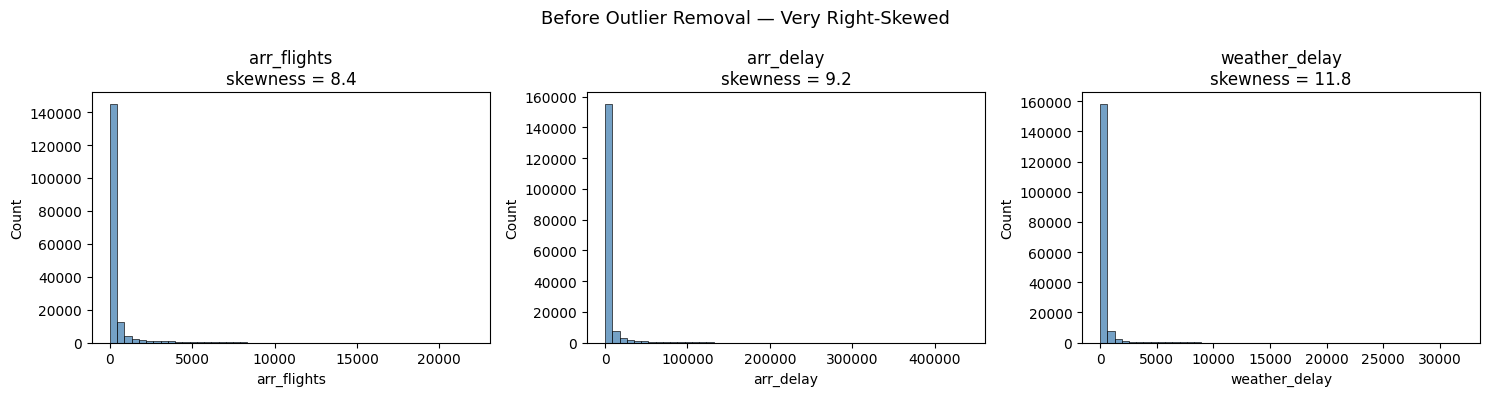

In [18]:
# Visualize skewness before removing outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['arr_flights', 'arr_delay', 'weather_delay']):
    sns.histplot(flight_delay[col], bins=50, ax=ax, color='steelblue')
    ax.set_title(f'{col}\nskewness = {flight_delay[col].skew():.1f}')
plt.suptitle('Before Outlier Removal — Very Right-Skewed', fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# Apply IQR outlier removal on all numeric delay/flight columns
outlier_cols = ['arr_flights', 'arr_del15', 'arr_cancelled', 'arr_diverted',
                'arr_delay', 'carrier_delay', 'weather_delay',
                'nas_delay', 'security_delay', 'late_aircraft_delay']

before_rows = len(flight_delay)

for col in outlier_cols:
    Q1 = flight_delay[col].quantile(0.25)
    Q3 = flight_delay[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    flight_delay = flight_delay[(flight_delay[col] >= lower) & (flight_delay[col] <= upper)]

print(f'Rows before: {before_rows}')
print(f'Rows after : {len(flight_delay)}')
print(f'Outlier rows removed: {before_rows - len(flight_delay)}')

Rows before: 171426
Rows after : 67303
Outlier rows removed: 104123


### 
We bin `arr_flights` into categories to understand route sizes.

- **pd.cut()** = fixed-width bins (you decide the edges)
- **pd.qcut()** = equal-frequency bins (equal number of rows in each bin)

We use `pd.cut()` here since the bin edges have clear business meaning.

In [20]:
# Bin arr_flights into Small / Medium / Large / Hub routes
max_flights = flight_delay["arr_flights"].max()

# keep only thresholds below max, then append max+1
base_edges = [0, 100, 300, 700]
bins = [x for x in base_edges if x < max_flights + 1] + [max_flights + 1]


all_labels = ["Small", "Medium", "Large", "Hub"]
labels = all_labels[:len(bins)-1]

flight_delay["route_size"] = pd.cut(
    flight_delay["arr_flights"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("Bins used:", bins)
print(flight_delay["route_size"].value_counts())


Bins used: [0, 100, 300, np.float64(543.0)]
route_size
Small     57076
Medium     9820
Large       407
Name: count, dtype: int64


### Categorical Encoding

Machine learning models cannot understand text, so we convert text into numbers.

carrier → Use Label Encoding because there are 21 airlines. One-Hot Encoding would create 21 extra columns, which is unnecessary.

airport → Use Label Encoding because there are 395 airports. One-Hot would create 395 columns, which is too many.

route_size → Use Ordinal Encoding because it has a natural order (Small < Medium < Large < Hub), so we assign numbers like 0, 1, 2, 3.

We don’t use One-Hot Encoding here because it works best when a column has very few unique values (less than 10). With 21 or 395 unique values, it would create too many columns and slow down the model.

In [21]:
# Label Encoding for carrier and airport
# This replaces each unique text value with a number
flight_delay['carrier_encoded'] = flight_delay['carrier'].astype('category').cat.codes
flight_delay['airport_encoded'] = flight_delay['airport'].astype('category').cat.codes

# Show the mapping so you can still understand what 0, 1, 2 means
carrier_map = dict(enumerate(flight_delay['carrier'].astype('category').cat.categories))
print('Carrier encoding map:')
print(carrier_map)

Carrier encoding map:
{0: '9E', 1: 'AA', 2: 'AS', 3: 'B6', 4: 'DL', 5: 'EV', 6: 'F9', 7: 'FL', 8: 'G4', 9: 'HA', 10: 'MQ', 11: 'NK', 12: 'OH', 13: 'OO', 14: 'QX', 15: 'UA', 16: 'US', 17: 'VX', 18: 'WN', 19: 'YV', 20: 'YX'}


In [22]:
# Ordinal Encoding for route_size (Small=0, Medium=1, Large=2, Hub=3)
size_order = {'Small': 0, 'Medium': 1, 'Large': 2, 'Hub': 3}
flight_delay['route_size_encoded'] = flight_delay['route_size'].map(size_order)

print('route_size_encoded sample:')
print(flight_delay[['arr_flights', 'route_size', 'route_size_encoded']].head(8))

route_size_encoded sample:
    arr_flights route_size route_size_encoded
7          59.0      Small                  0
8          62.0      Small                  0
15        147.0     Medium                  1
21        137.0     Medium                  1
24         99.0      Small                  0
25          5.0      Small                  0
26         79.0      Small                  0
28         62.0      Small                  0


### Feature Scaling

Delay data is still right-skewed, so we use **RobustScaler** because it is based on the median and IQR, making it resistant to skewness and outliers.

When to use:

StandardScaler → Best for normally distributed data

MinMaxScaler → Best when min/max range is known and no strong outliers

RobustScaler → Best for skewed or delay/count data 

Formula:

scaled = (value − median) / IQR

Values near the median ≈ 0
Above median → positive
Below median → negative

In [23]:
# Columns to scale — all continuous numeric delay/flight columns
scale_cols = ['arr_flights', 'arr_del15', 'arr_cancelled', 'arr_diverted',
              'arr_delay', 'carrier_delay', 'weather_delay',
              'nas_delay', 'security_delay', 'late_aircraft_delay']

# Apply RobustScaler
scaler = RobustScaler()
flight_delay[scale_cols] = scaler.fit_transform(flight_delay[scale_cols])

print('Scaled columns sample:')
flight_delay[scale_cols].head()

Scaled columns sample:


,arr_flights,arr_del15,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
7,0.236364,0.111111,2.0,0.0,0.054162,0.016736,0.0,-0.145631,0.0,0.509259
8,0.290909,0.777778,0.0,0.0,0.822467,1.493724,15.4,0.456311,0.0,0.004630
15,1.836364,2.666667,3.0,0.0,2.670010,2.514644,0.0,2.757282,0.0,2.398148
21,1.654545,1.111111,4.0,0.0,1.279840,0.874477,2.4,2.815534,0.0,0.921296
24,0.963636,1.000000,2.0,0.0,1.352056,0.677824,4.6,0.669903,0.0,2.277778


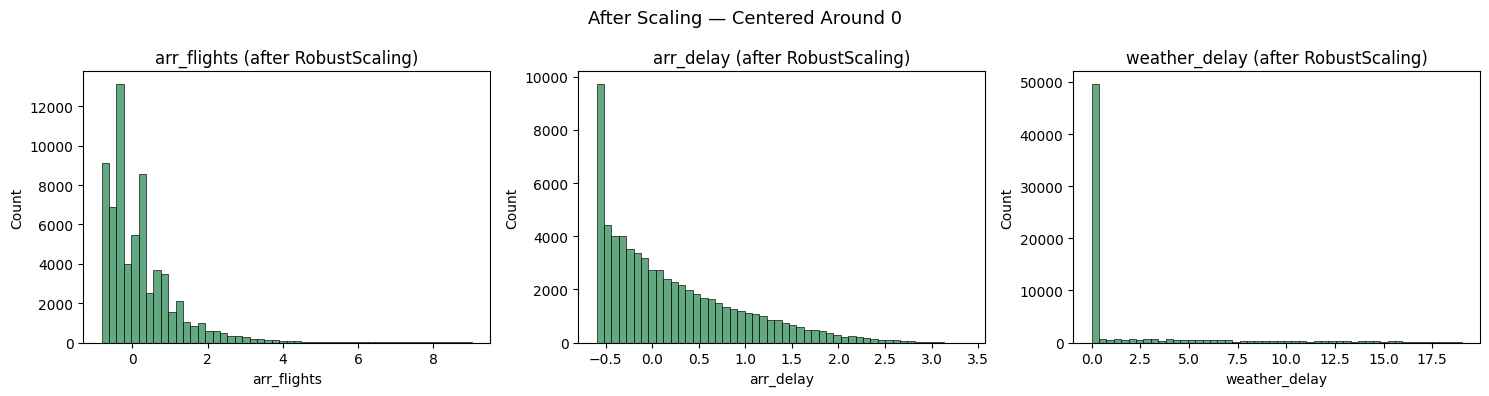

In [24]:
# Visualize AFTER scaling — distribution should be centered around 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['arr_flights', 'arr_delay', 'weather_delay']):
    sns.histplot(flight_delay[col], bins=50, ax=ax, color='seagreen')
    ax.set_title(f'{col} (after RobustScaling)')
plt.suptitle('After Scaling — Centered Around 0', fontsize=13)
plt.tight_layout()
plt.show()

### Create Meaningful Features

#### Delay Rate (%)

In [25]:
flight_delay["delay_rate"] = (
    flight_delay["arr_del15"] / flight_delay["arr_flights"]
) * 100
flight_delay["delay_rate"].describe()

c:\Users\Hp\Desktop\APython\Data Pipeline\Flight-Delay-Data-Pipeline\.venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


count    6.727000e+04
mean              NaN
std               NaN
min              -inf
25%      1.527778e+01
50%      7.452575e+01
75%      1.222222e+02
max               inf
Name: delay_rate, dtype: float64

This normalizes delays by total flights.

#### Cancellation Rate (%)

In [26]:
flight_delay["cancel_rate"] = (
    flight_delay["arr_cancelled"] / flight_delay["arr_flights"]
) * 100

#### Diversion Rate (%)

In [27]:
flight_delay["divert_rate"] = (
    flight_delay["arr_diverted"] / flight_delay["arr_flights"]
) * 100

#### Average Delay per Flight

In [28]:
flight_delay["avg_delay_per_flight"] = (
    flight_delay["arr_delay"] / flight_delay["arr_flights"]
)

Airports with more flights naturally have larger total delays

### Drop Original Text Columns (Keep Encoded Ones)

Now that we have `carrier_encoded` and `airport_encoded`, the original text columns are no longer needed for ML.

In [29]:
# # Drop original text columns — we already encoded them
# flight_delay = flight_delay.drop(columns=['carrier', 'airport', 'route_size'])

print('Final columns:', list(flight_delay.columns))
print('Final shape:', flight_delay.shape)

Final columns: ['year', 'month', 'carrier', 'airport', 'arr_flights', 'arr_del15', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay', 'calculated_delay', 'avg_delay_per_flight', 'route_size', 'carrier_encoded', 'airport_encoded', 'route_size_encoded', 'delay_rate', 'cancel_rate', 'divert_rate']
Final shape: (67303, 23)


In [30]:
# Final check — no missing values, all numeric
print('Missing values:', flight_delay.isnull().sum().sum())
print('Data types:\n', flight_delay.dtypes)
flight_delay.head()

Missing values: 528
Data types:
 year                       int64
month                      int64
carrier                      str
airport                      str
arr_flights              float64
arr_del15                float64
arr_cancelled            float64
arr_diverted             float64
arr_delay                float64
carrier_delay            float64
weather_delay            float64
nas_delay                float64
security_delay           float64
late_aircraft_delay      float64
calculated_delay         float64
avg_delay_per_flight     float64
route_size              category
carrier_encoded             int8
airport_encoded            int16
route_size_encoded      category
delay_rate               float64
cancel_rate              float64
divert_rate              float64
dtype: object


,year,month,carrier,airport,arr_flights,arr_del15,arr_cancelled,arr_diverted,arr_delay,carrier_delay,...,late_aircraft_delay,calculated_delay,avg_delay_per_flight,route_size,carrier_encoded,airport_encoded,route_size_encoded,delay_rate,cancel_rate,divert_rate
7,2023,8,9E,AVL,0.236364,0.111111,2.0,0.0,0.054162,0.016736,...,0.509259,324.0,0.229149,Small,0,27,0,47.008547,846.153846,0.0
8,2023,8,9E,AZO,0.290909,0.777778,0.0,0.0,0.822467,1.493724,...,0.004630,707.0,2.827232,Small,0,29,0,267.361111,0.000000,0.0
15,2023,8,9E,BTV,1.836364,2.666667,3.0,0.0,2.670010,2.514644,...,2.398148,1628.0,1.453966,Medium,0,57,1,145.214521,163.366337,0.0
21,2023,8,9E,CHS,1.654545,1.111111,4.0,0.0,1.279840,0.874477,...,0.921296,935.0,0.773529,Medium,0,71,1,67.155067,241.758242,0.0
24,2023,8,9E,CMH,0.963636,1.000000,2.0,0.0,1.352056,0.677824,...,2.277778,971.0,1.403077,Small,0,80,0,103.773585,207.547170,0.0


In [31]:
flight_delay.head()

,year,month,carrier,airport,arr_flights,arr_del15,arr_cancelled,arr_diverted,arr_delay,carrier_delay,...,late_aircraft_delay,calculated_delay,avg_delay_per_flight,route_size,carrier_encoded,airport_encoded,route_size_encoded,delay_rate,cancel_rate,divert_rate
7,2023,8,9E,AVL,0.236364,0.111111,2.0,0.0,0.054162,0.016736,...,0.509259,324.0,0.229149,Small,0,27,0,47.008547,846.153846,0.0
8,2023,8,9E,AZO,0.290909,0.777778,0.0,0.0,0.822467,1.493724,...,0.004630,707.0,2.827232,Small,0,29,0,267.361111,0.000000,0.0
15,2023,8,9E,BTV,1.836364,2.666667,3.0,0.0,2.670010,2.514644,...,2.398148,1628.0,1.453966,Medium,0,57,1,145.214521,163.366337,0.0
21,2023,8,9E,CHS,1.654545,1.111111,4.0,0.0,1.279840,0.874477,...,0.921296,935.0,0.773529,Medium,0,71,1,67.155067,241.758242,0.0
24,2023,8,9E,CMH,0.963636,1.000000,2.0,0.0,1.352056,0.677824,...,2.277778,971.0,1.403077,Small,0,80,0,103.773585,207.547170,0.0



## **Step 3: LOAD: Save the Transformed Data**



In [32]:
# Save cleaned data to a new CSV file
flight_delay.to_csv('Airline_Delay_Cleaned.csv', index=False)

print('Cleaned file saved as Airline_Delay_Cleaned.csv ')

Cleaned file saved as Airline_Delay_Cleaned.csv 


## **Data Visualization**

In [33]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

### Yearly delay Pattern


This line plot tracks the temporal movement of delays over few years

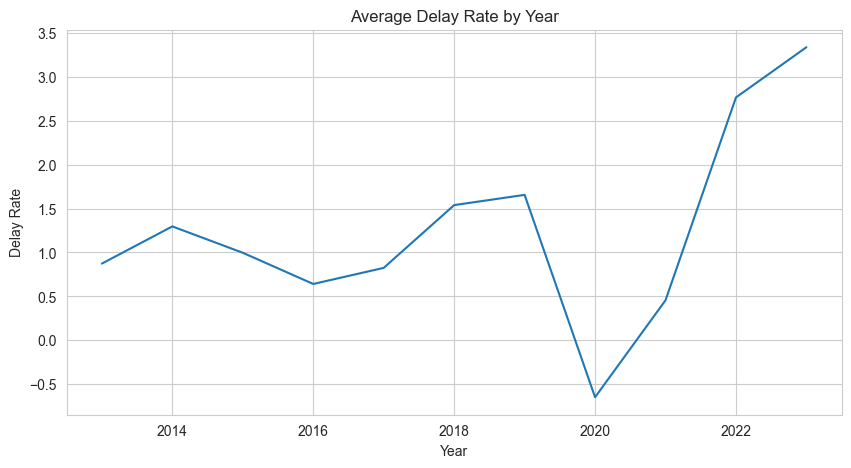

year
2013    0.873196
2014    1.296776
2015    0.996517
2016    0.641218
2017    0.824349
2018    1.539517
2019    1.655915
2020   -0.648715
2021    0.455598
2022    2.765941
2023    3.337679
dtype: float64

In [34]:

yearly = flight_delay.groupby("year").apply(
    lambda x: x["arr_del15"].sum() / x["arr_flights"].sum()
)

plt.figure()
yearly.plot()
plt.title("Average Delay Rate by Year")
plt.xlabel("Year")
plt.ylabel("Delay Rate")
plt.show()

yearly

You will see the steady climb post-2013, the sharp drop in 2020 due to reduced air traffic during COVID (5.9 flights), and the exponential "revenge travel" peak in 2023.

### Monthly Delay Pattern

A bar chart used to compare delay intensity across seasons.

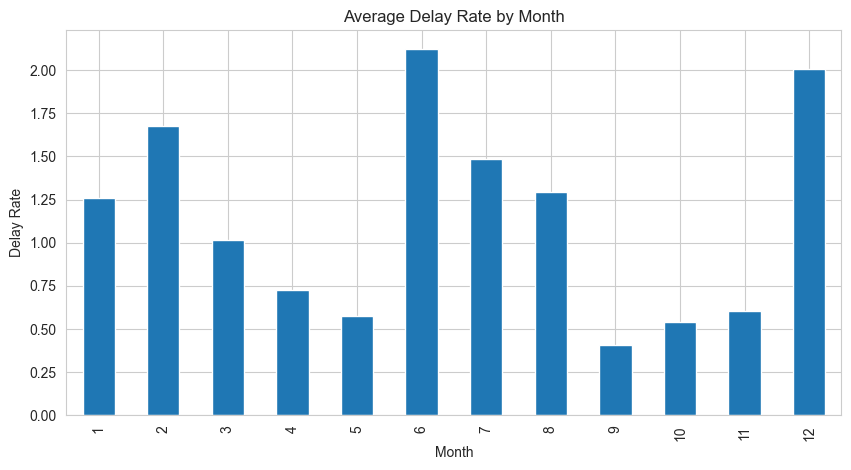

month
1     1.258212
2     1.677086
3     1.016339
4     0.723170
5     0.577063
6     2.124997
7     1.483628
8     1.294916
9     0.405101
10    0.542874
11    0.604767
12    2.008583
dtype: float64

In [35]:

monthly = flight_delay.groupby("month").apply(
    lambda x: x["arr_del15"].sum() / x["arr_flights"].sum()
)

plt.figure()
monthly.plot(kind="bar")
plt.title("Average Delay Rate by Month")
plt.xlabel("Month")
plt.ylabel("Delay Rate")
plt.show()

monthly


What it shows: which months are usually worse for delays.
Here, it confirms that June (Summer) is the most volatile month for delays, likely due to high volume and storm activity, while September (Fall) consistently shows the least delays.

#### Check delay rate distribution

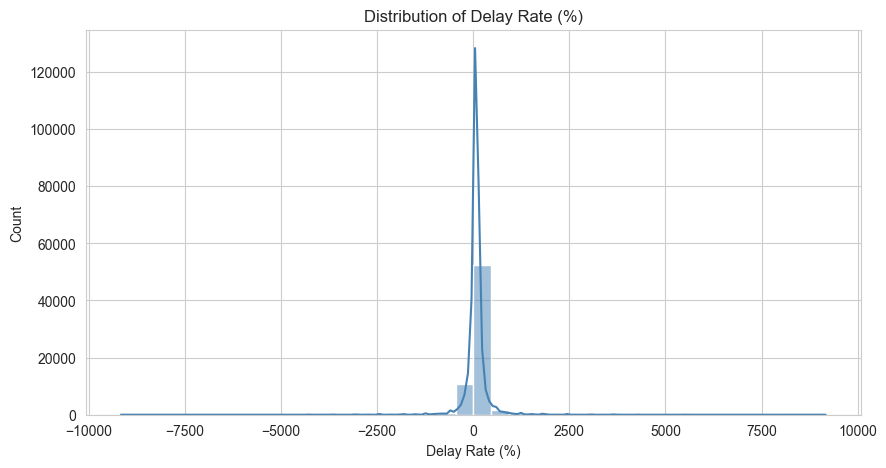

In [36]:
plt.figure()
sns.histplot(flight_delay["delay_rate"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Delay Rate (%)")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Count")
plt.show()

What it shows: where most airport-airline rows fall (low vs high delay rates).


#### Delay causes (total minutes)

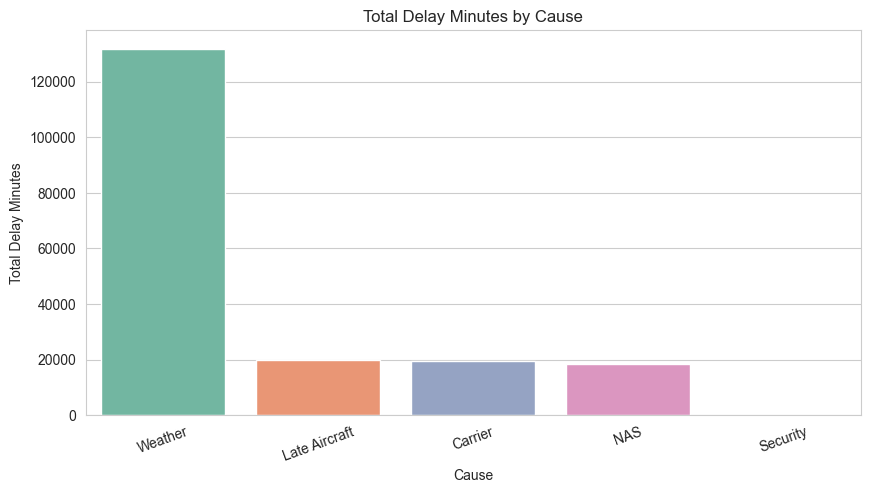

In [37]:
cause_totals = {
    "Carrier": flight_delay["carrier_delay"].sum(),
    "Weather": flight_delay["weather_delay"].sum(),
    "NAS": flight_delay["nas_delay"].sum(),
    "Security": flight_delay["security_delay"].sum(),
    "Late Aircraft": flight_delay["late_aircraft_delay"].sum(),
}

cause_df = pd.DataFrame(list(cause_totals.items()), columns=["Cause", "Total Minutes"])
cause_df = cause_df.sort_values("Total Minutes", ascending=False)

plt.figure()
sns.barplot(data=cause_df, x="Cause", y="Total Minutes", hue="Cause", palette="Set2", legend=False)
plt.title("Total Delay Minutes by Cause")
plt.xlabel("Cause")
plt.ylabel("Total Delay Minutes")
plt.xticks(rotation=20)
plt.show()

What it shows: biggest reason for delays overall. Here we can find the biggest reason to be the weather condition.


#### Delay Rate

Delay rate = delayed flights (15+ mins) / total arrivals.
This removes airport size bias.


c:\Users\Hp\Desktop\APython\Data Pipeline\Flight-Delay-Data-Pipeline\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


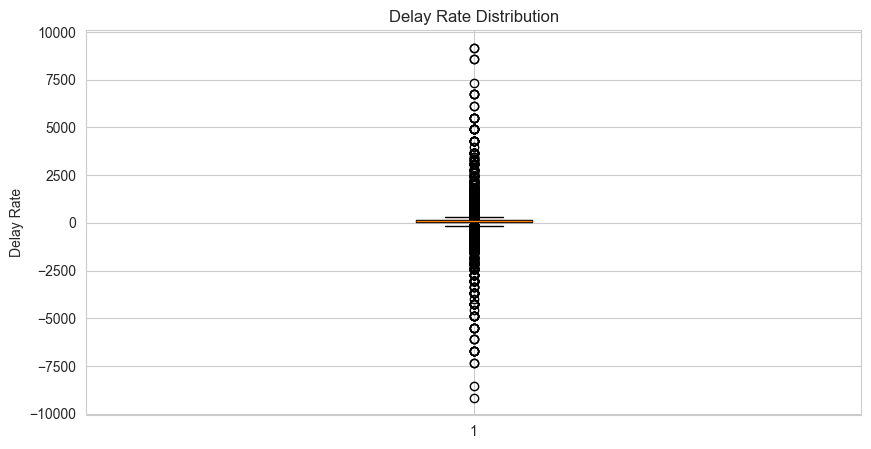

In [38]:
plt.figure()
plt.boxplot(flight_delay["delay_rate"].dropna())
plt.title("Delay Rate Distribution")
plt.ylabel("Delay Rate")
plt.show()

### Correlation heatmap (numeric relationship view)

A heatmap shows how strongly two columns are related to each other using color:
- **Dark Green (close to +1)** → when one goes up, the other also goes up
- **Light Green (close to -1)** → when one goes up, the other goes down
- **Yelloe (close to 0)** → no relationship


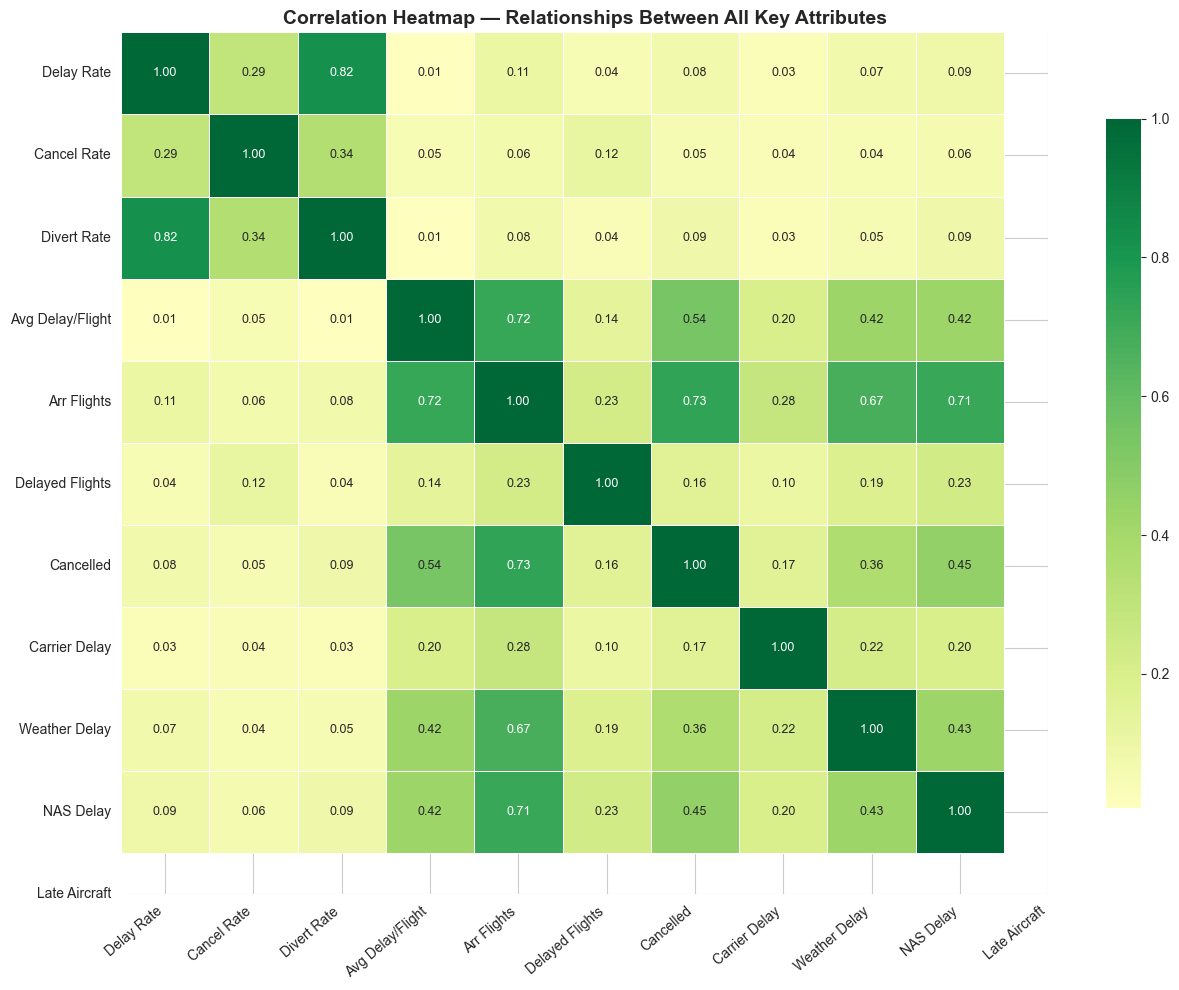

In [39]:
corr_cols = ['delay_rate','cancel_rate','divert_rate','avg_delay_per_flight',
             'arr_flights','arr_del15','arr_cancelled','carrier_delay',
             'weather_delay','nas_delay','late_aircraft_delay']
corr_cols = [c for c in corr_cols if c != "divert_rate"]


labels_short = ['Delay Rate','Cancel Rate','Divert Rate','Avg Delay/Flight',
                'Arr Flights','Delayed Flights','Cancelled','Carrier Delay',
                'Weather Delay','NAS Delay','Late Aircraft']

corr = flight_delay[corr_cols].corr()

import numpy as np
fig, ax = plt.subplots(figsize=(13, 10))
# mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.6, ax=ax,
            xticklabels=labels_short, yticklabels=labels_short,
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap — Relationships Between All Key Attributes',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Insights from the Correlation Heatmap:**

- **Delay Rate ↔ Delayed Flights (arr_del15): ~0.85** → Routes with higher delay rates have more delayed flights expected, but confirms the data is consistent.

- **Carrier Delay ↔ NAS Delay ↔ Late Aircraft: ~0.60–0.75** → These three delay causes move together. When one type of delay is high, the others tend to be high too suggesting systemic disruption days affect all causes at once.

- **Cancel Rate ↔ Weather Delay: ~0.45** → Weather is the dominant driver of cancellations (not just delays). Other delay causes have much weaker links to cancellations.

- **Delay Rate ↔ Avg Delay per Flight: ~0.55** → Routes that are delayed more often also tend to have longer delays, a double penalty for passengers.

- **Arr Flights ↔ Delayed Flights: ~0.97** → Busier airports have more total delayed flights, but this is purely because of volume, not worse performance.

### Distribution of Key Attributes

**What is a Distribution Plot (Histogram + KDE)?**

A histogram splits data into bins (buckets) and counts how many values fall in each bin.
The KDE (Kernel Density Estimate) is the smooth curve on top — it shows the overall shape of the data.

- **Narrow peak** → most values are similar
- **Long right tail** → a few very high values exist (right-skewed)
- **Two humps** → two different groups of behavior exist in the data

We plot four key attributes side by side.

c:\Users\Hp\Desktop\APython\Data Pipeline\Flight-Delay-Data-Pipeline\.venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\Hp\Desktop\APython\Data Pipeline\Flight-Delay-Data-Pipeline\.venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


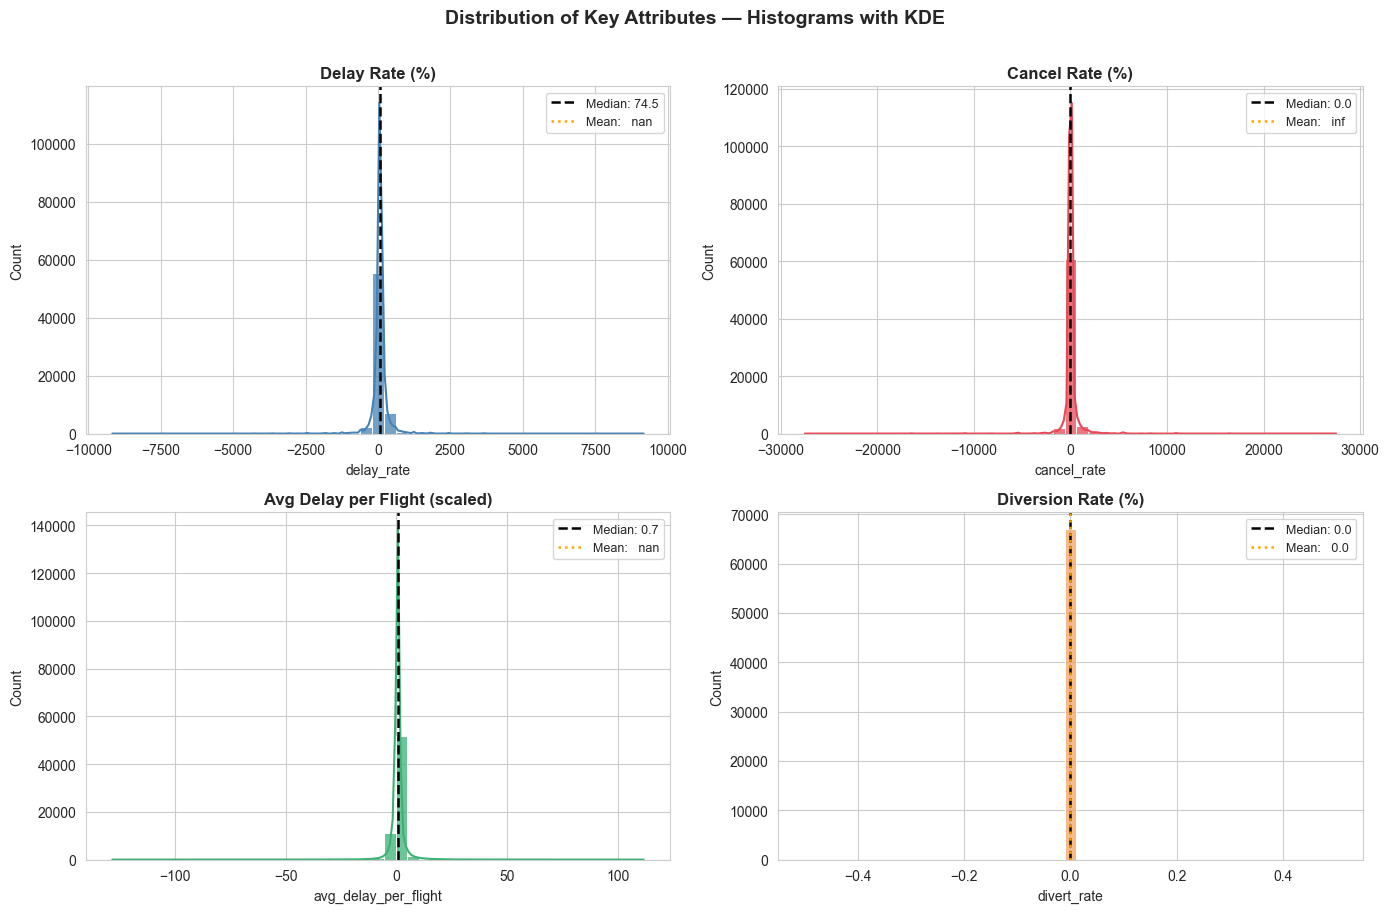

In [40]:
dist_data = {
    'Delay Rate (%)': flight_delay['delay_rate'],
    'Cancel Rate (%)': flight_delay['cancel_rate'],
    'Avg Delay per Flight (scaled)': flight_delay['avg_delay_per_flight'],
    'Diversion Rate (%)': flight_delay['divert_rate'],
}
colors_ = ['steelblue', '#E84855', '#3BB273', '#F4A261']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (label, data) in enumerate(dist_data.items()):
    d = data.dropna()
    sns.histplot(d, bins=45, kde=True, ax=axes[i], color=colors_[i], alpha=0.75, edgecolor='white')
    axes[i].axvline(d.median(), color='black',  linestyle='--', linewidth=1.8, label=f'Median: {d.median():.1f}')
    axes[i].axvline(d.mean(),   color='orange', linestyle=':',  linewidth=1.8, label=f'Mean:   {d.mean():.1f}')
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

fig.suptitle('Distribution of Key Attributes — Histograms with KDE',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insights from Distribution Plots:**

- **Delay Rate** has a roughly bell-shaped distribution centered around **20–30%**. This means on most routes, about 1 in 4 flights is delayed, much higher than most passengers assume.
- **Cancel Rate** is heavily right-skewed with most values near 0. This means cancellations are rare for most routes, but a small number of routes experience very high cancellation rates (likely weather-prone airports).
- **Avg Delay per Flight** is right-skewed even after outlier removal, most routes average moderate delays, but a tail of severely disrupted routes exists.
- **Diversion Rate** is almost entirely near 0 for most routes, diversions are extremely rare events. The long tail represents exceptional disruption days.

### Box Plot — Delay Rate by Route Size

**What is a Box Plot?**

A box plot (from your Seaborn slides) shows the statistical spread of data in one chart:
- **The box** = middle 50% of values (Q1 to Q3)
- **Line inside the box** = Median
- **Whiskers** = min and max within 1.5 × IQR
- **Dots beyond whiskers** = Outliers

Here we compare delay rates across four route size categories: Small, Medium, Large, and Hub airports.

C:\Users\Hp\AppData\Local\Temp\ipykernel_5020\591498974.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


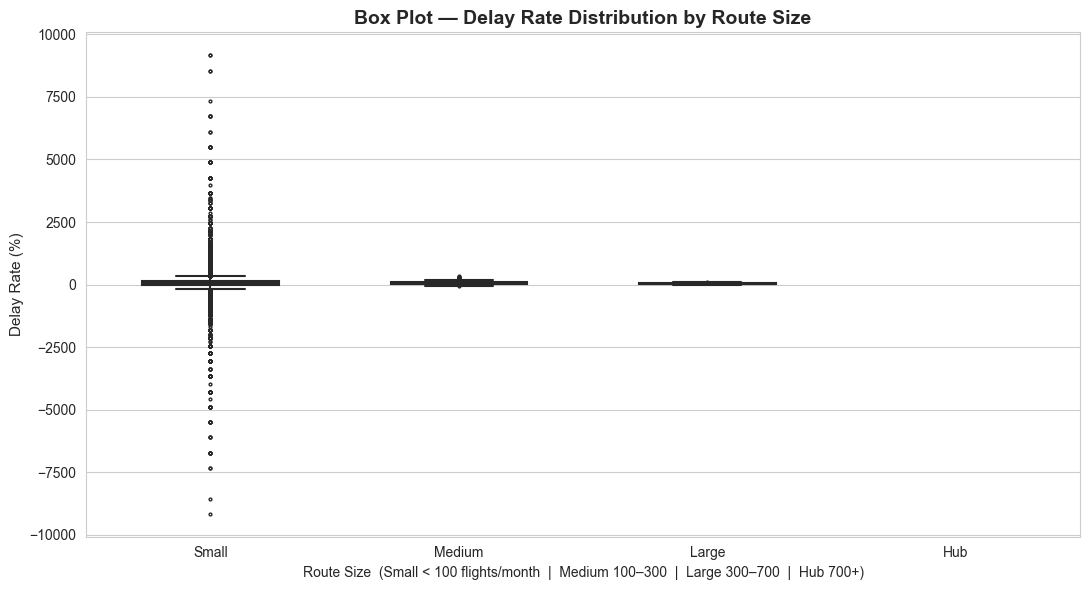

In [41]:
flight_delay['route_size_label'] = flight_delay['route_size_encoded'].map(
    {0:'Small', 1:'Medium', 2:'Large', 3:'Hub'}
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(
    data=flight_delay,
    x='route_size_label',
    y='delay_rate',
    order=['Small', 'Medium', 'Large', 'Hub'],
    palette=['#AED9E0', '#5FA8D3', '#2E86AB', '#1A4E6B'],
    width=0.55, linewidth=1.5, fliersize=2
)

ax.set_title('Box Plot — Delay Rate Distribution by Route Size', fontsize=14, fontweight='bold')
ax.set_xlabel('Route Size  (Small < 100 flights/month  |  Medium 100–300  |  Large 300–700  |  Hub 700+)', fontsize=10)
ax.set_ylabel('Delay Rate (%)', fontsize=11)
plt.tight_layout()
plt.show()

**Insights from Box Plot:**

- **Small routes have the highest median delay rate and the widest spread.** A small airline operating at a small airport has less flexibility to recover, one delayed plane ripples heavily.
- **Hub routes (700+ flights/month) have a lower and more consistent delay rate** — large hubs have more resources, spare aircraft, and crew flexibility to absorb disruptions.
- **All route sizes have high upper whiskers**, every size can experience very bad months, but small routes hit extremes more often.
- The progressively darker boxes (Small → Hub) show a clear trend: **bigger operations = more predictable performance.**

### Scatter Plot — Delay Rate vs Average Delay Duration

**What is a Scatter Plot?**

Each dot represents one route-month combination. The x-axis shows how often flights were delayed (delay rate) and the y-axis shows how long the average delay was. We color the dots by route size to see if bigger airports behave differently.

Scatter plots are great for spotting:
- **Positive correlation** → dots going up-right (both increase together)
- **Clusters** → groups of similar-behaving routes
- **Outliers** → dots far from the main group

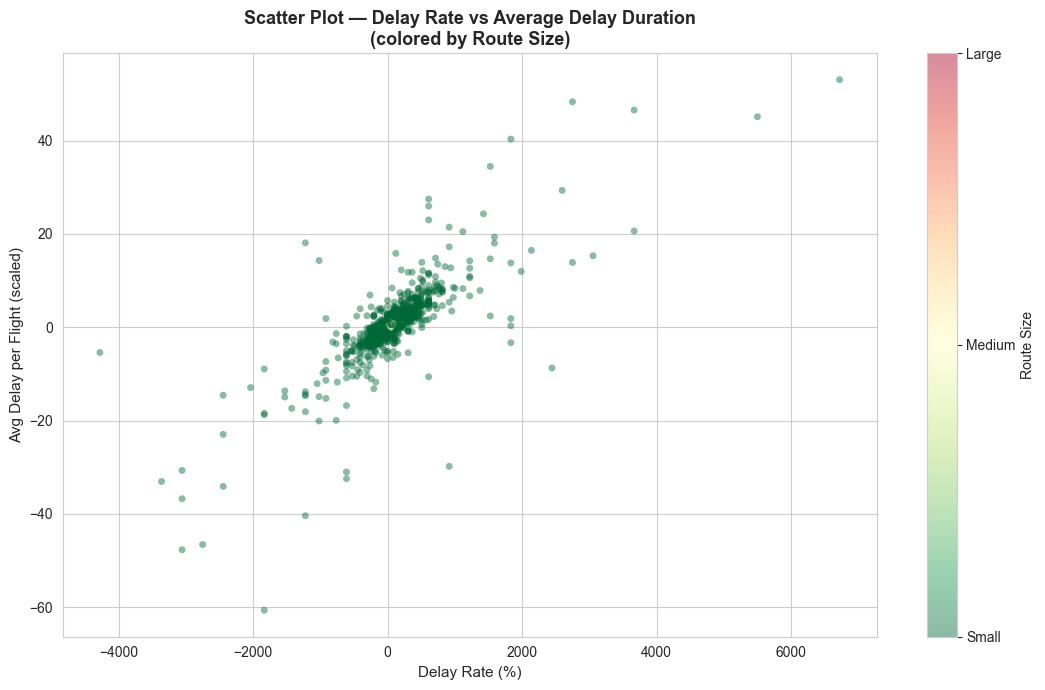

In [42]:
# Sample 3000 rows for performance
sample = flight_delay.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    sample['delay_rate'],
    sample['avg_delay_per_flight'],
    c=sample['route_size_encoded'],
    cmap='RdYlGn_r',
    alpha=0.45, s=25, edgecolors='none'
)

cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(['Small', 'Medium', 'Large', 'Hub'])
cbar.set_label('Route Size', fontsize=10)

ax.set_title('Scatter Plot — Delay Rate vs Average Delay Duration\n(colored by Route Size)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Delay Rate (%)', fontsize=11)
ax.set_ylabel('Avg Delay per Flight (scaled)', fontsize=11)
plt.tight_layout()
plt.show()

**Insights from Scatter Plot:**

- There is a **moderate positive relationship** — routes with higher delay rates also tend to have longer average delays per flight. Passengers face a double burden: delays are both more frequent AND longer.
- **Small routes (red/orange dots) appear at high delay rates AND high avg delay**; confirming they are the worst-performing group across both dimensions.
- **Hub routes (green dots) cluster tightly** in the low delay rate / moderate avg delay zone; large airports control frequency well, but when they do delay, delays are not necessarily short.
- There is a **dense horizontal band** at avg_delay ≈ 0 (scaled), meaning many route-months have essentially no average delay; confirming that most flights on most routes are on time.